![Henry Logo](https://www.soyhenry.com/_next/static/media/HenryLogo.bb57fd6f.svg)



# M3L1 Extra E01 - Tool Contracts
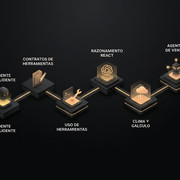

*Figura E01. Contrato de tool: entrada clara, validacion y salida estable.*

## Proposito

Este notebook trabaja una idea central: las tools conectan al agente con el mundo real, pero deben estar bien diseñadas.

Una **custom tool** productiva necesita:

- responsabilidad unica;
- inputs claros;
- outputs predecibles;
- validacion;
- errores interpretables;
- posibilidad de testearse de manera aislada.

En este ejercicio vas a construir tools para consultar ventas y calcular ingresos.


## Definiciones clave

| Concepto | Definicion | En este ejercicio |
|---|---|---|
| Tool contract | Forma estable de entrada y salida de una tool. | `fetch_sales()` devuelve siempre `success`, `period`, `sales`, `error`. |
| Input validation | Rechazar o normalizar entradas invalidas. | `normalize_period()` limpia y valida el periodo. |
| Error handling | Convertir fallos en mensajes interpretables. | `success=False` y `error` descriptivo. |
| Grounding | Basar la respuesta en datos reales. | Las ventas salen de `SALES_DB`. |
| Tool deterministica | Funcion verificable sin LLM. | `calculate_revenue()` calcula con Python. |

Idea clave: el LLM no deberia inventar datos ni calcular todo mentalmente si una tool puede hacerlo de forma mas confiable.


## C?mo encaja este notebook en un AI Agent

Este notebook no implementa el loop ReAct completo. Se enfoca en una pieza previa: que las **tools** sean confiables.

En una arquitectura de agente, estas funciones entrarian asi:

```text
Thought: necesito consultar ventas del periodo.
Action: fetch_sales("2024-W01")
Observation: {"success": True, "sales": [...]}

Thought: ahora necesito calcular el total.
Action: calculate_revenue(sales)
Observation: {"success": True, "total_usd": 100}
```

La observacion es util porque la tool devuelve un contrato estable. Si el contrato cambia todo el tiempo, el agente no puede construir un trace confiable ni decidir la accion a tomar.


## Paso 1 - Entender la fuente de datos

`SALES_DB` simula una base de datos interna. En un agente real podria ser SQL, CRM, ERP o una API privada.

El agente no deberia inventar ventas: deberia pedirle datos a una tool.


In [ ]:
SALES_DB = {
    "2024-W01": [
        {"product": "Pro", "units": 3, "unit_price_usd": 20},
        {"product": "Starter", "units": 5, "unit_price_usd": 8},
    ]
}


### El primer principio: validar antes de actuar

Una tool robusta necesita una regla simple antes de actuar:

> **Inputs claros y tipados.** La funcion comunica que recibe, que devuelve
> y que errores puede lanzar.

La normalizacion es un paso previo a cualquier consulta: si el periodo esta mal
formado, no tiene sentido ir a buscar datos.

Patron defensivo:

```text
entrada del usuario
      |
      v
normalize_period()  <- rechaza o limpia
      |
      v
fetch_sales()       <- consulta solo si el input es valido
```

Esto evita que errores de tipeo del usuario lleguen hasta la base de datos.


## Paso 2 - TODO 1: normalizar el input

Completa `normalize_period(period)`.

Por que importa:

- el usuario puede escribir espacios;
- puede usar minusculas;
- puede mandar `None`;
- una tool robusta debe limpiar o rechazar antes de consultar datos.

Implementacion esperada:

1. Si `period` no es `str`, devolver `None`.
2. Aplicar `strip()`.
3. Aplicar `upper()`.
4. Si queda vacio, devolver `None`.
5. Si es valido, devolver el periodo normalizado.


In [ ]:
def normalize_period(period):
    # TODO 1: validar que period sea str, strip(), upper() y devolverlo.
    # Si no es str o queda vacio, devolver None.
    pass


### Por qu? el contrato de salida importa tanto como la l?gica

Imagina que en un caso devuelves `{"sales": [...]}` y en otro devuelves `None`.

El agente que llama a esta tool necesita hacer:

```python
if resultado["success"]:
    procesar(resultado["sales"])
else:
    print(resultado["error"])
```

Si el contrato cambia, el agente se rompe. Regla práctica:

> "Una tool no deberia devolver formatos impredecibles."

La forma recomendada es siempre devolver un dict con `success`, los datos y `error`.
Asi el agente puede tomar decisiones sin importar si la tool tuvo exito o fallo.


## Paso 3 - TODO 2: buscar ventas con output estable

Completa `fetch_sales(period)`.

El objetivo no es solo buscar datos. El objetivo es devolver siempre el mismo contrato:

```python
{
    "success": bool,
    "period": str | None,
    "sales": list,
    "error": str | None,
}
```

Esto permite que un agente pueda decidir que hacer despues sin interpretar excepciones crudas.


In [ ]:
def fetch_sales(period):
    # TODO 2: usar normalize_period y devolver siempre el shape estandar.
    # Si el periodo es invalido -> success=False, error descriptivo.
    # Si no hay ventas -> success=False, error descriptivo, sales=[] .
    # Si hay ventas -> success=True, period, sales, error=None.
    pass


### Tools de c?lculo: determinismo vs estimaci?n

Las **tools de calculo** sirven para:

> "Calculos deterministicos donde no queremos depender del razonamiento
> aproximado del LLM."

En este caso, `calculate_revenue` no es solo una multiplicacion simple. Incluye:

- conversion de tipos (`units` puede venir como string desde una DB),
- manejo de claves faltantes (si un registro no tiene `unit_price_usd`),
- captura de errores inesperados.

Estos detalles hacen la diferencia entre un calculo que "funciona en demo"
y uno que sobrevive datos sucios en produccion.


## Paso 4 - TODO 3: calcular revenue con seguridad

Completa `calculate_revenue(sales)`.

Esto es una tool de calculo: sirve para tareas deterministicas donde no queremos depender del razonamiento aproximado del LLM.

Reglas:

- si `sales` no es lista o esta vacia, devolver fallo estructurado;
- convertir `units` a `int`;
- convertir `unit_price_usd` a `float`;
- capturar errores de clave o tipo;
- devolver `total_usd` si todo salio bien.


In [ ]:
def calculate_revenue(sales):
    # TODO 3: validar lista de ventas y calcular total_usd.
    # Si sales no es lista o esta vacia -> success=False.
    # Si hay error de clave/tipo -> success=False.
    # Si funciona -> success=True, total_usd, error=None.
    pass


## Paso 5 - Ejecutar checks

Los checks funcionan como contrato ejecutable.

Validan:

- normalizacion de `" 2024-w01 "` a `"2024-W01"`;
- calculo total de 100 USD;
- error controlado para periodo inexistente;
- error controlado para input invalido.


In [ ]:
def run_checks():
    ok = fetch_sales(" 2024-w01 ")
    assert ok["success"] is True
    assert ok["period"] == "2024-W01"
    total = calculate_revenue(ok["sales"])
    assert total["success"] is True
    assert total["total_usd"] == 100

    missing = fetch_sales("2024-W99")
    assert missing["success"] is False
    assert missing["sales"] == []

    bad = fetch_sales(None)
    assert bad["success"] is False

    print("M3L1 E01 Starter checks passed")


run_checks()


## Cierre conceptual

Una tool bien diseñada reduce el riesgo de que el agente invente o rompa el flujo.

Diferencia clave:

| Tool fragil | Tool robusta |
|---|---|
| Devuelve formas distintas. | Devuelve contrato estable. |
| Lanza errores crudos. | Devuelve errores interpretables. |
| No valida inputs. | Valida antes de actuar. |
| Dificil de testear. | Se prueba con asserts. |
